# **SC1003 Project: Student Allocation Simulator**

---

### **Team Members**
* Keith Mok
* Aarjav Jain
* Ian Tan
* Vanessa Khoo
* Koh Joon Yong

---

### **Table of Contents**
1.  Introduction
2.  Problem Decomposition
3.  Data Analysis
4.  Algorithm Design

5.  Implementation
6.  Algorithm Evaluation
7.  Appendix: File Upload
8.  Conclusion





---


## 1. **Introduction**

This project aims to solve a complex allocation problem for the "Introduction to Data Science" course. With 6,000 students across 120 tutorial groups, the course coordinator needs an automated way to create 10 teams of 5 for each group.

Our objective is to develop a Python simulator that:
1.  Loads and processes the student data.
2.  Implements an advanced allocation algorithm to form teams.
3.  Prioritizes balancing multiple conflicting constraints: **Gender Diversity**, **School Diversity**, and **CGPA consistency**.
4.  Validates the resulting teams and reports on the algorithm's success.

---


## 2. **Problem Decomposition**

### Key Requirements

Based on the project brief and our own goals, we defined four key requirements:
1.  **Group Integrity:** All teams must be formed from students within the *same* tutorial group.
2.  **Gender Diversity:** Each team should have a healthy mix of genders.
3.  **School Diversity:** Each team should have a mix of students from different schools.
4.  **CGPA Balance:** The average CGPA of all 10 teams within a tutorial group should be as consistent as possible.

We quickly realized these rules are in **direct conflict**. For example, forcing a gender or school swap can unbalance the CGPA. Our final algorithm is a custom solution designed to prioritize these conflicting constraints.

---


## 3. **Data Analysis**

### Dataset Overview
* **File:** `records.csv`
* **Total Students:** 6,000
* **Tutorial Groups:** 120
* **Students per Group:** 50
* **Teams to create:** 1,200 (10 teams for each of the 120 groups)
* **Data Structure:** Each student has a Tutorial Group, Student ID, School, Name, Gender, and CGPA.

---

## 4. **Algorithm Design**

Our algorithm is designed as a **multi-phase, greedy approach** to solve the core challenge of balancing three conflicting constraints: **Gender Diversity**, **School Diversity**, and **CGPA Consistency**.

The algorithm operates on one tutorial group (50 students) at a time and is broken into two main stages: **Sorting** and **Allocation**.

### 1. Sorting Strategy (`sort_teams`)

Before we can allocate, we must prepare the list of 50 students. To tackle gender and CGPA balance simultaneously, the `sort_teams` function does the following:

1.  **Segregate by Gender:** Students are split into two lists: `Group_F` (Females) and `Group_M` (Males).
2.  **Sort by CGPA:** Both lists are sorted *independently* by CGPA in descending order (highest to lowest).
3.  **Merge Lists:** The sorted `Group_M` is appended to the end of the sorted `Group_F`.

This creates a single, sorted list: `[All Females (sorted high-low), All Males (sorted high-low)]`. This design ensures that when the allocation (snake draft) begins, high-performing students of both genders are picked early and distributed evenly, rather than all high-CGPA students (regardless of gender) being clustered in the first few teams.

### 2. Allocation Strategy (`allocate_teams`)

Once the list is sorted, the `allocate_teams` function distributes the students using a **3-pass snake draft** to ensure all teams are filled and diversity rules are met.

1.  **Pass 1: Strict Snake Draft**
    * The algorithm iterates through the sorted list using a "snake draft" (Team 1 -> 10, then Team 10 -> 1) to ensure balanced CGPA distribution.
    * The **primary rule is School Diversity**. A student is placed in their target team *only if* that team has **fewer than 2** students from their school.
    * If their target team fails this rule, the algorithm tries the other teams. If no team can take them under this strict rule, they are added to a `leftovers` list.

2.  **Pass 2: Relaxed Leftover Pass**
    * The algorithm loops through the `leftovers` list from Pass 1.
    * The school rule is now **relaxed to fewer than 3** students. This places most remaining students, making a small trade-off in perfect school diversity to avoid leaving students unassigned.
    * Students who *still* cannot be placed (e.g., all 10 teams already have 3 students from their school) are added to a final `Leftleftovers` list.

3.  **Pass 3: Fallback Pass**
    * For any students in the `Leftleftovers` list, this pass places them in the first available team with **fewer than 5 members**, ignoring all diversity rules.
    * This final pass is a fail-safe that **guarantees 100% placement** and ensures all teams have exactly 5 members.

This 3-pass greedy approach prioritizes our constraints in the following order:

1. **Team Size** (100% placement)
2. **School Diversity** (strict, then relaxed)
3. **CGPA/Gender Balance** (handled by the initial sort and draft).

The detailed, line-by-line logic for each function is presented below in the **Pseudocode** section and visualized in the **Flowchart**.


# **Pseudocode**

```
FUNCTION extract_csv(filename)

Initialize empty list for data

    OPEN filename as file

      READ all lines in file into list called lines
      REMOVE all newlines from first value in lines (first line in csv)
      SPLIT the first value in lines by commas to get list of headers

      FOR line in lines starting from second line(starting from students):
          REMOVE all leading/trailing spaces or newlines
          SPLIT line by commas to get list of values
          CREATE dictionary pairing headers and values
          APPEND dictionary to data list

    CLOSE the file

RETURN data list
```

```
FUNCTION process_student_data(student_data_list):

    Create an empty dictionary called tutorial_groups

    For each student in student_data_list:
        Get the student's tutorial group name from the "Tutorial Group" field
        If this group name is not already a key in tutorial_groups:
            Create a new key in tutorial_groups with an empty list as its value
        Append the student dictionary to the list for that group in tutorial_groups

    RETURN tutorial_groups
```


`get_student_id` `update_student_id` `get_cgpa` `sort_teams` `update_team_index` `get_team_index`

```
FUNCTION get_student_id(student)
    
    GET student' ID
    RETURN student's ID

END FUNCTION


FUNCTION update_student_id(all_final_allocations)
    
    FOR tutorial group, teams in all_final_allocations.items()
      FOR team in teams
        FOR student in team
          CALL the function get_student_id(student) to get all the student ID and update accordingly
END FUNCTION
```

```
FUNCTION get_cgpa(student)
    
    Return student's CGPA value
END FUNCTION

FUNCTION sort_teams(student_list, target_size)
    
    number of teams = total students / target size of teams
    
    Separate students by gender
    Group_F = empty list
    Group_M = empty list

    FOR each student IN student_list DO
        IF student.Gender == "Female" THEN
            ADD student TO Group_F
        ELSE IF student.Gender == "Male" THEN
            ADD student TO Group_M
        END IF
    END FOR
    
    SORT Group_F by CGPA in descending order
    SORT Group_M by CGPA in descending order
    

    FOR each male_student IN Group_M DO
        ADD male_student TO Group_F
    END FOR

    TotalGPA = Group_F
    
    RETURN TotalGPA, target_size, No_of_teams
END FUNCTION
```
```
FUNCTION update_team_index(tutorial_group)
    
    FOR team_index, team in tutorial_group (index starts at 1)
      FOR student in team
        student["Team Index"] = team_index
END FUNCTION

```
```

FUNCTION allocate_teams(TotalGPA, target_size, No_of_teams)

    all_teams = list of number of teams empty lists
    team_school_counts = list of number of teams empty dictionaries
    counter = 0  
    flag = True  
    leftovers = empty list  
    

    FOR each student IN TotalGPA DO
        teams_to_try = [counter] + [all other team indices]
        
        placed = False
        
        FOR each team_idx IN teams_to_try DO
            IF (count of school in team_school_counts[team_idx] < 2 AND
                length of all_teams[team_idx] < target_size) THEN
                ADD student TO all_teams[team_idx]
                INCREMENT team_school_counts[team_idx][school] by 1
                placed = True
                BREAK
            END IF
        END FOR
        
        IF NOT placed THEN
            ADD student TO leftovers
        END IF
        
        IF flag == True THEN  // Moving forward
            IF counter == No_of_teams - 1 THEN
                flag = False  // Reached end, reverse direction
            ELSE
                counter = counter + 1  // Move to next team
            END IF

        ELSE  // Moving backward
            IF counter == 0 THEN
                flag = True  // Reached start, go forward again
            ELSE
                counter = counter - 1  // Move to previous team
            END IF
        END IF
    END FOR
    
    
    FOR each student IN leftovers DO
        SET placed = False
        SET school = student's school
        
        FOR team_idx FROM 0 TO (No_of_teams - 1) DO
            IF (count of school in team_school_counts[team_idx] < 3 AND
                length of all_teams[team_idx] < target_size) THEN
            
                ADD student TO all_teams[team_idx]
                INCREMENT team_school_counts[team_idx][school] by 1
                SET placed = True
                BREAK
            END IF
        END FOR
        
        IF NOT placed THEN
            ADD student TO Leftleftover
        END IF
    END FOR

    IF length of Leftleftover > 0 THEN
        FOR each student IN Leftleftover DO
            FOR team_idx FROM 0 TO (No_of_teams - 1) DO
                IF length of all_teams[team_idx] < target_size THEN
                    ADD student TO all_teams[team_idx]
                    BREAK
                END IF
            END FOR
        END FOR
    END IF
    
    CALL function update_team_index(all_teams)
    RETURN all_teams

END FUNCTION
```

```
FUNCTION get_team_index(team)
    
    team_index = team[0]["Team Index"]
    return team_index
    
END FUNCTION
```

## Functions checking Gender Balance
#### ```gender_stats```,```gender_balance_check```,```check_tutorial_group_gender_balance```, ```check_gender_diversity```


```
FUNCTION gender_stats(team)
    
    SET females TO 0
    SET males TO 0
    
    FOR EACH student IN team DO
        IF student's Gender is "Female" THEN
            INCREMENT females BY 1
        ELSE IF student's Gender is "Male" THEN
            INCREMENT males BY 1
        END IF
    END FOR
    
    RETURN females, males
END FUNCTION
```
```
FUNCTION gender_balance_check(females, team_size)
    
    CALCULATE gender_balance_requirement AS ceiling of (team_size / 2)
    CALCULATE gender_proportion_upper AS gender_balance_requirement / team_size
    CALCULATE gender_proportion_lower AS 1 - gender_proportion_upper
    CALCULATE female_proportion AS females / team_size
    SET gender_balance TO False
    
    IF gender_proportion_lower <= female_proportion <= gender_proportion_upper THEN
        SET gender_balance TO True
    END IF
    
    RETURN gender_balance, gender_proportion_upper, gender_proportion_lower
END FUNCTION
```
```
FUNCTION check_tutorial_group_gender_balance(tutorial_group, gender_proportion_upper, gender_proportion_lower)
    
    GET tutorial_group_size AS 50
    SET females TO 0
    
    FOR EACH team IN tutorial_group DO
        FOR EACH student IN team DO
            IF student's Gender is "Female" THEN
                INCREMENT females BY 1
            END IF
        END FOR
    END FOR
    
    CALCULATE female_proportion AS females / tutorial_group_size
    SET gender_balance TO False
    
    IF gender_proportion_lower <= female_proportion <= gender_proportion_upper THEN
        SET gender_balance TO True
    END IF
    
    RETURN gender_balance
END FUNCTION
```
```
FUNCTION check_gender_diversity(tutorial_group)
    
    CREATE empty list gender_diversity_list
    
    FOR EACH team IN tutorial_group DO
        GET team_index BY CALLING get_team_index(team)
        GET females, males BY CALLING gender_stats(team)
        GET gender_balance, upperBound, lowerBound
            BY CALLING gender_balance_check(females, length of team)
        SET tutorial_group_diversity TO True
        
        IF NOT gender_balance THEN
            GET tutorial_group_balance BY CALLING
                check_tutorial_group_gender_balance(tutorial_group, upperBound, lowerBound)
            
            IF NOT tutorial_group_balance THEN
                SET tutorial_group_diversity TO False
            END IF
        END IF
        
        APPEND tuple (team_index, gender_balance, females, tutorial_group_diversity)
            TO gender_diversity_list
    END FOR
    
    RETURN gender_diversity_list
END FUNCTION
```

## Functions Checking School Diversity:
#### ```school_stats```,```check_school_diversity_team```,```check_school_diversity```
```
FUNCTION school_stats(team)
    
    CREATE empty dictionary school_counts

    FOR EACH student IN team
        GET school FROM student

        IF school NOT IN school_counts THEN
            SET school_counts[school] TO 1
        ELSE
            INCREMENT school_counts[school] BY 1
        END IF
    END FOR

    RETURN school_counts
END FUNCTION
```
```
FUNCTION check_school_diversity_team(school_stats, team_size)
    
    CALCULATE max_school AS team_size divided by 2 (integer division)
    SET school_diversity TO True
    SET failed_school TO None
    SET failed_school_count to 0

    FOR EACH school, count IN school_stats DO
        IF count > max_school THEN
            SET school_diversity TO False
            SET failed_school TO school
            SET failed_school_count TO count
        END IF
    END FOR

    RETURN school_diversity, failed_school, failed_school_count
END FUNCTION
```
```
FUNCTION school_diversity_tutorial_group(tutorial_group, failed_school, max_school)
    SET no_of_teams TO 10
    CREATE empty dictionary total_school_counts
    
    FOR EACH team IN tutorial_group DO
        FOR EACH student IN team DO
            GET school FROM student
            
            IF school NOT IN total_school_counts THEN
                SET total_school_counts[school] TO 1
            ELSE
                INCREMENT total_school_counts[school] BY 1
            END IF
        END FOR
    END FOR
    
    IF failed school IN total_school_counts THEN
      IF total_school_counts[failed_school] > (max_school * no_of_teams) THEN
          RETURN False
    END IF
    
    RETURN True
END FUNCTION
```
```
FUNCTION check_school_diversity(tutorial_group)
    
    CREATE empty list school_diversity_list
    
    FOR EACH team IN tutorial_group DO
        SET school_balanced TO True
        GET team_index BY CALLING get_team_index(team)
        GET school_count_dict BY CALLING school_stats(team)
        GET school_diversity, failed_school, failed_school_count, max_school
            BY CALLING check_school_diversity_team(school_count_dict, length of team)
        GET tutorial_group_sch_diversity BY CALLING school_diversity_tutorial_group(tutorial_group, failed_school, max_school
        
        IF NOT school_diversity THEN
            SET school_balanced TO False
        END IF
        
        APPEND tuple (team_index, school_balanced, failed_school, failed_school_count, tutorial_group_sch_diversity)
            TO school_diversity_list
    END FOR
    
    RETURN school_diversity_list
END FUNCTION
```

## Functions Checking CGPA Diversity:
#### ```obtain_mean_cgpa```,```cgpa_diversity_check```
```
FUNCTION obtain_mean_cgpa(team)
    
    SET totalCGPA TO 0
    
    FOR EACH student IN team DO
        GET cgpa FROM student and CONVERT TO float
        ADD cgpa TO totalCGPA
    END FOR
    
    CALCULATE meanCGPA AS totalCGPA / length of team
    
    RETURN meanCGPA
END FUNCTION
```
```
FUNCTION cgpa_diversity_check(tutorial_group)
    
    CREATE empty list cgpa_mean
    SET cgpa_diversity TO False
    
    FOR EACH team IN tutorial_group DO
        GET meanCGPA BY CALLING obtain_mean_cgpa(team)
        APPEND meanCGPA TO cgpa_mean
    END FOR
    
    CALCULATE diversity_score AS standard deviation of cgpa_mean
    
    IF diversity_score < 0.1 THEN
        SET cgpa_diversity TO True
    END IF
    
    RETURN cgpa_diversity, diversity_score
END FUNCTION
```

## Functions Checking Team Size Requirement:
#### ```check_team_size```,```team_size_check```
```
FUNCTION check_team_size(team)
    
    SET team_size_pass TO False
    
    IF length of team equals 5 THEN
        SET team_size_pass TO True
    END IF
    
    RETURN team_size_pass, length of team
END FUNCTION
```
```
FUNCTION team_size_check(tutorial_group)
    
    CREATE empty list team_size_checklist
    
    FOR EACH team IN tutorial_group DO
        GET team_index BY CALLING get_team_index(team)
        GET team_size_pass, team_size BY CALLING check_team_size(team)
        APPEND tuple (team_index, team_size_pass, team_size) TO team_size_checklist
    END FOR
    
    RETURN team_size_checklist
END FUNCTION
```

## Main Checking Function:
#### ```print_results```,```check_requirements```
```
FUNCTION print_results(requirements_dict)
    
    FOR EACH groupname, data IN requirements_dict DO
        PRINT "-----Tutorial Group {groupname}-----"
        
        FOR EACH teamIndex, dataset IN data DO
            CREATE empty list constraints
            
            FOR EACH constraint, results IN dataset DO
                APPEND "[{constraint}: {results}]" TO constraints
            END FOR
            
            JOIN all elements in constraints into joined_constraints string
            PRINT "Team {teamIndex}: {joined_constraints}"
        END FOR
    END FOR
END FUNCTION
```
```
FUNCTION check_requirements(tutorial_group_index, tutorial_group)
    
    CREATE dictionary requirements_dict with tutorial_group_index as key and empty dictionary as value
    
    GET gender_diversity_list BY CALLING check_gender_diversity(tutorial_group)
    GET school_diversity_list BY CALLING check_school_diversity(tutorial_group)
    GET cgpa_pass, _ BY CALLING cgpa_diversity_check(tutorial_group)
    GET team_size_checklist BY CALLING team_size_check(tutorial_group)
    
    IF cgpa_pass THEN
        SET cgpa_constraint TO "PASS"
    ELSE
        SET cgpa_constraint TO "FAIL"
    END IF
    
    FOR EACH team IN gender_diversity_list DO
        GET team_index FROM team[0]
        GET gender_pass FROM team[1]
        GET numFemales FROM team[2]
        GET tut_group_diversity FROM team[3]
        
        IF gender_pass THEN
            SET gender_constraint TO "PASS"
        ELSE
            SET gender_constraint TO "FAIL: {numFemales} Females"
            
            IF NOT tut_group_diversity THEN
                SET gender_constraint TO "FAIL: {numFemales} Females (Due to lack of gender diversity in tutorial group)"
            END IF
        END IF
        
        SET requirements_dict[tutorial_group_index][team_index] TO dictionary with:
            "Team Size": None
            "CGPA": cgpa_constraint
            "Gender": gender_constraint
            "School": None
    END FOR
    
    FOR EACH team IN school_diversity_list DO
        GET team_index FROM team[0]
        GET school_pass FROM team[1]
        GET failed_school FROM team[2]
        GET failed_school_count FROM team[3]
        
        IF school_pass THEN
            SET school_constraint TO "PASS"
        ELSE
            SET school_constraint TO "FAIL: {failed_school_count} from {failed_school}"
        END IF
        
        SET requirements_dict[tutorial_group_index][team_index]["School"] TO school_constraint
    END FOR
    
    FOR EACH team IN team_size_checklist DO
        GET team_index FROM team[0]
        GET team_size_pass FROM team[1]
        GET team_size FROM team[2]
        
        IF team_size_pass THEN
            SET team_size_constraint TO "PASS"
        ELSE
            SET team_size_constraint TO "FAIL Team has {team_size} people"
        END IF
        
        SET requirements_dict[tutorial_group_index][team_index]["Team Size"] TO team_size_constraint
    END FOR
    
    CALL print_results(requirements_dict)
    
    RETURN requirements_dict
END FUNCTION
```

```
FUNCTION `export_allocations_to_csv(all_final_allocations, filename="FDDA_Team2_IanTan.csv"):`

    OPEN a new csv file called "FDDA_Team2_IanTan.csv" in write mode

    WRITE the header list "Tutorial Group, Student ID,School,Name,Gender,CGPA,Team Assigned"

    FOR each tutorial groups and the corresponding list in team in all_final_allocations:
      FOR team in teams:
          FOR student in team:
            CREATE a list called row which contains the following:
                [
                Tutorial Group
                student's ID
                student's School
                student's Name
                student's Gender
                student's CGPA
                student's Team Index
                ]

    JOIN all the element in row with comma and write the resulting line into the file

    CREATE a new list called e_row
      FOR each item in row
      IF the item contains a comma
          ADD quotes around the item
            APPEND the modified item into e_row

    JOIN all the elememt in e_row with a comma
    WRITE the resultant line into the csv file called "FDDA_Team2_IanTan.csv"

END FUNCTION
```

```
FUNCTION `main()`

    LOAD student data by calling on the function extract_csv("records.csv")
    STORE result under student_data

    PROCESS student data into tutorial groups
    STORE the result under grouped_data

    CREATE a empty dictionary called all_final_allocations

    FOR each tutorial group name and student list in grouped_data
    
      CALL the function sort_teams(student_list, 10)
      store the return values under TotalGPA, target_size and No_of_teams

      CALL the function allocate_teams(TotalGPA, target_size, No_of_teams)
      STORE the return values under allocated_teams

      ADD all the entry into the dictionary called all_final_allocations
      all_final_allocations[tutorial_group_name] = allocated_teams

    FOR each tutorial group name and and its allocated team in all_final_allocations
      CALL the funtion check_requirements(tutorial_group_name, allocated_teams)to check if all teams fulfill the requirement for Gender, School and CGPA

    CALL the function update_student_id(student) to update all the student ID before exporting to csv file

    CALL the function export_allocations_to_csv(all_final_allocations, filename="FDDA_Team2_IanTan.csv") to export all the finalised allocation of each teams for each tutorial group into the new csv file called "FDDA_Team2_IanTan.csv"

    
    CALL main()

END FUNCTION
```

# **Flowchart**

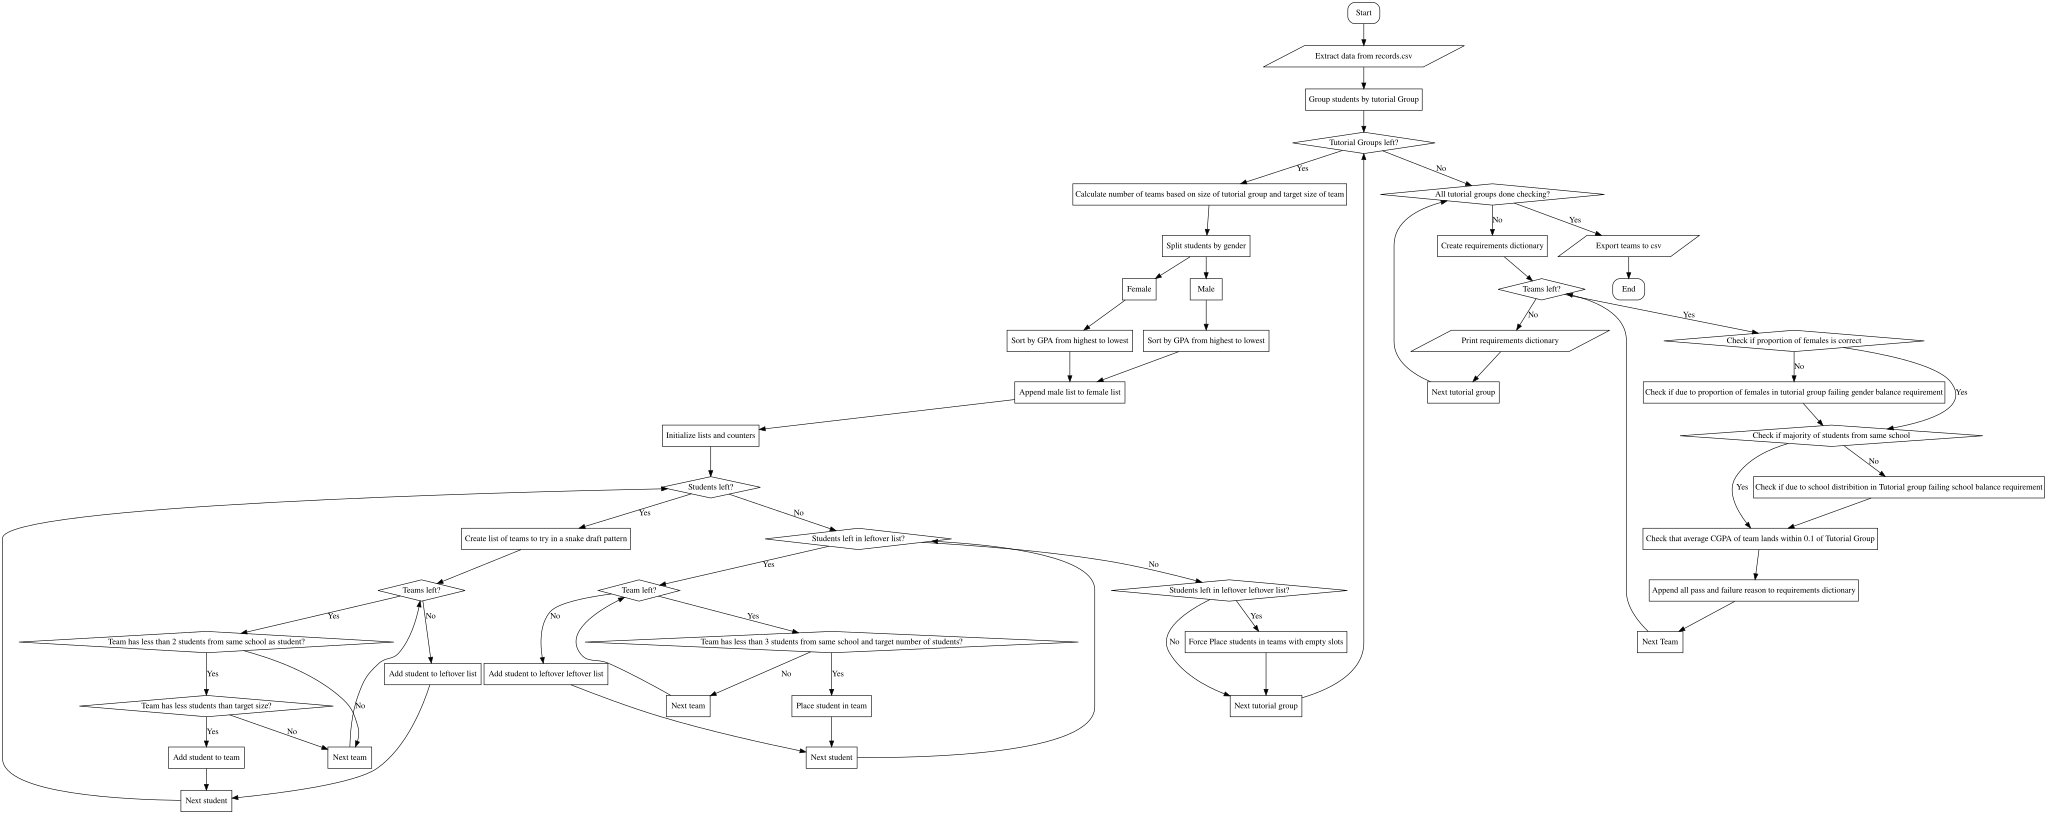

In [ ]:
#!apt-get install graphviz -q
#!pip install graphviz -q
from graphviz import Digraph

dot = Digraph()

dot.attr(rankdir="TB")
dot.attr("node", shape="box")

dot.node("A", "Start",shape="rectangle",style="rounded")
dot.node("B", "Extract data from records.csv",shape="parallelogram")
dot.node("C", "Group students by tutorial Group")
dot.node("D","Tutorial Groups left?",shape="diamond")
dot.node("E", "Calculate number of teams based on size of tutorial group and target size of team")
dot.node("F", "Split students by gender")
dot.node("G", "Female")
dot.node("H", "Male")
dot.node("I","Sort by GPA from highest to lowest")
dot.node("J","Sort by GPA from highest to lowest")
dot.node("K","Append male list to female list")
dot.node("L","Initialize lists and counters")
dot.node("M","Students left?",shape="diamond")
dot.node("N","Create list of teams to try in a snake draft pattern")
dot.node("O","Teams left?",shape="diamond")
dot.node("P","Team has less than 2 students from same school as student?",shape="diamond")
dot.node("Q","Team has less students than target size?",shape="diamond")
dot.node("R","Add student to team")
dot.node("S","Next team")
dot.node("T","Add student to leftover list")
dot.node("U","Next student")
dot.node("V","Students left in leftover list?",shape="diamond")
dot.node("VV","Students left in leftover leftover list?",shape="diamond")
dot.node("W","Team left?",shape="diamond")
dot.node("WW","Add student to leftover leftover list")
dot.node("XX","Force Place students in teams with empty slots")
dot.node("X","Team has less than 3 students from same school and target number of students?",shape="diamond")
dot.node("Y","Place student in team")
dot.node("Z","Next student")
dot.node("AA","Next team")
dot.node("BB","Next tutorial group")
dot.node("BBB","All tutorial groups done checking?",shape="diamond")
dot.node("CC","Create requirements dictionary")
dot.node("CCC","Teams left?",shape="diamond")
dot.node("DD","Check if proportion of females is correct",shape="diamond")
dot.node("DDD","Check if due to proportion of females in tutorial group failing gender balance requirement")
dot.node("EE","Check if majority of students from same school",shape="diamond")
dot.node("EEE","Check if due to school distribition in Tutorial group failing school balance requirement")
dot.node("FF","Check that average CGPA of team lands within 0.1 of Tutorial Group")
dot.node("GG","Append all pass and failure reason to requirements dictionary")
dot.node("HH","Next Team")
dot.node("JJ","Print requirements dictionary",shape="parallelogram")
dot.node("JJJ","Next tutorial group")
dot.node("KK","Export teams to csv",shape="parallelogram")
dot.node("LL","End",style="rounded")


dot.edges(["AB", "BC", "CD","EF", "FG","FH","GI","HJ","IK","JK","KL","LM"])
dot.edge("D","E",label="Yes")
dot.edge("M","N",label="Yes")
dot.edge("N","O")
dot.edge("O","P",label="Yes")
dot.edge("P","Q",label="Yes")
dot.edge("Q","R",label="Yes")
dot.edge("P","S",label="No")
dot.edge("Q","S",label="No")
dot.edge("S","O")
dot.edge("O","T",label="No")
dot.edge("R","U")
dot.edge("T","U")
dot.edge("U","M")
dot.edge("M","V",label="No")
dot.edge("V","W",label="Yes")
dot.edge("W","X",label="Yes")
dot.edge("W","WW",label="No")
dot.edge("WW","Z")
dot.edge("X","Y",label="Yes")
dot.edge("Y","Z")
dot.edge("Z","V")
dot.edge("X","AA",label="No")
dot.edge("AA","W")
dot.edge("V","VV",label="No")
dot.edge("VV","BB",label="No")
dot.edge("VV","XX",label="Yes")
dot.edge("XX","BB")
dot.edge("BB","D",)
dot.edge("CC","CCC")
dot.edge("CCC","DD",label="Yes")
dot.edge("DD","EE",label="Yes")
dot.edge("DD","DDD",label="No")
dot.edge("DDD","EE")
dot.edge("EE","EEE",label="No")
dot.edge("EE","FF",label="Yes")
dot.edge("EEE","FF")
dot.edge("FF","GG")
dot.edge("GG","HH")
dot.edge("HH","CCC")
dot.edge("D","BBB",label="No")
dot.edge("BBB","CC",label="No")
dot.edge("CCC","JJ",label="No")
dot.edge("JJ","JJJ")
dot.edge("JJJ","BBB")
dot.edge("BBB","KK",label="Yes")
dot.edge("KK","LL")

dot.render("flowchart", format="png", cleanup=True)
dot

---
# **Implementation**


---

### Data Extraction (`extract_csv` function)

This function extracts the headers and data from the csv to create a list of dictionaries, with each student being a different dictionary.

1.  **Open & Read File:** The function opens the CSV file (specified by the `records` argument) and reads all lines into a list called `lines`.
2.  **Extract Headers:** It processes the **first line** (`lines[0]`). It strips any whitespace (like newlines) and splits the line by commas to create a `headers` list (e.g., `['Name', 'CGPA', 'School', 'Gender']`).
3.  **Iterate Rows:** The function then loops through every **remaining line** in the file (from `lines[1:]` onwards).
4.  **Create Dictionaries:** For each data line, it:
    * Strips and splits the line into a `values` list (e.g., `['Alice', '3.8', 'Engineering', 'F']`).
    * Uses `zip` to pair the `headers` list with the `values` list.
    * Converts these pairs into a `student_dict` (e.g., `{'Name': 'Alice', 'CGPA': '3.8', ...}`).
    * Appends this `student_dict` to the main `data` list.
5.  **Output:** The function returns the complete `data` list, which now holds one dictionary for each student (row) from the CSV file.

In [ ]:
def extract_csv(records):
  data = []
  with open(records, 'r') as file:
    lines = file.readlines()
    headers = lines[0].strip().split(',')

    for line in lines[1:]:
      values = line.strip().split(',')
      student_dict = dict(zip(headers,values))
      data.append(student_dict)

    return data


I wrote a function called 'process_student_data' which accepts the list
produced by Member 1 and organizes those student records by tutorial groups. Basically, it creates an empty dictionary and then it loops through every student dictionary. It reads the tutorial group field (also trims the whitespaces), creates a list for the group the first time it appears, and then appends the student dictionary to that list. Finally, it returns the dictionary of groups so Member 3 can take any single group's list and run the team allocation task.

I tried to break the problem into a clear sequence of high-level steps so everyone can follow the logic without seeing implementation details. I start by declaring the procedure and the input, then initialize the container for groups, iterate over each student, extract and trim the tutorial group name, create a new list for a group only when it first appears, append the student to that group, and finally return the grouped dictionary. This idea of decomposition makes the plan easy to review, and the abstraction keeps the specification concise so any teammate can implement it in code clearly.            


In [ ]:
def process_student_data(student_data_list):
    tutorial_groups = {}

    for student in student_data_list:
        group = student.get("Tutorial Group", "").strip()
        if group not in tutorial_groups:
            tutorial_groups[group] = []
        tutorial_groups[group].append(student)

    return tutorial_groups


---
### Allocation of teams



This function contains the main allocation algorithm. It uses a 3-pass snake draft to distribute the sorted students into 10 teams, prioritizing school diversity and CGPA balance while ensuring all students are placed.


In [ ]:
def get_cgpa(student):
    #Helper function for sorting
    return student["CGPA"]

In [ ]:
def get_student_id(student):
  student.get("Student ID")
  return student.get("Student ID")

In [ ]:
def update_student_id(all_final_allocations):
    for tutorial_group,teams in all_final_allocations.items():
        for team in teams:
          for student in team:
            student["ID"] = get_student_id(student)



In [ ]:
def update_team_index(tutorial_group):
    for team_index, team in enumerate(tutorial_group, start = 1):
        for student in team:
            student["Team Index"] = team_index

---

### Part 1: Sort & Prepare (`sort_teams`)

This function takes the full `student_list` and prepares it for the main allocation algorithm by sorting it based on gender and CGPA.

1.  **Calculate Target Size:** It first determines the base `target_size` (the base number of students per team) using integer division (`len(student_list) // No_of_teams`).

2.  **Split by Gender:** The code iterates through the `student_list` and segregates all students into two new lists: `Group_F` (females) and `Group_M` (males).

3.  **Sort by CGPA:** Both the `Group_F` and `Group_M` lists are sorted independently by CGPA in **descending order** (highest CGPA appears first).

4.  **Combine Lists:** A final `TotalGPA` list is created by appending the *entire* sorted `Group_M` to the end of the *entire* sorted `Group_F`.

5.  **Final Order:** The resulting `TotalGPA` list is now ordered as: `[All Females (sorted high-to-low CGPA), All Males (sorted high-to-low CGPA)]`.

6.  **Output:** The function returns the sorted `TotalGPA` list, the calculated `target_size`, and the original `No_of_teams` to be used by the allocation function.

In [ ]:
def sort_teams(student_list, target_size):
    #Function to sort the teams base on Gender and GPA

    No_of_teams = ceil(len(student_list) / target_size)
    # How many teams

    Group_F = [Female for Female in student_list if Female["Gender"] == "Female"]
    Group_M = [Male for Male in student_list if Male["Gender"] == "Male"]
    #In the student list check the Gender and put it in a list for that gender

    Group_F.sort(key=get_cgpa, reverse=True)
    Group_M.sort(key=get_cgpa, reverse=True)
    #Sort lsit for both male and female base on the CGPA and order from highest to lowest

    for i in Group_M:
      Group_F.append(i)
      #Add one list to another

    TotalGPA = Group_F

    return TotalGPA, target_size , No_of_teams



---

### Part 2: Main Allocation Loop (`allocate_teams`)

#### Initialization
The function first initializes several variables to manage the "snake draft" allocation:
* **`all_teams`**: A list of empty lists (one for each team).
* **`team_school_counts`**: A list of empty dictionaries to track school counts per team.
* **`leftovers`**: An empty list to hold students who cannot be placed under strict rules.
* **`counter`**: Set to `0`. This pointer indicates which team is "up" to receive a student.
* **`flag`**: Set to `True`. This controls the direction of the `counter` (True = increment, False = decrement).

#### Main Loop Logic
The code iterates through every student in the `TotalGPA` list (the order determined in Part 1). For each student:

1.  **Prioritize Team:** A `teams_to_try` list is created. The team indicated by the `counter` is placed *first* in this list, followed by all other teams.
2.  **Set `placed` Flag:** A tracker variable `placed` is reset to `False` for the current student.
3.  **Start Inner Loop:** The code loops through the `teams_to_try` list, checking the `counter` team first.

#### Inner Loop: Checking Strict Rules
For each team in `teams_to_try`, the code checks two strict conditions:
* **Rule A (School):** Does this team have **less than 2** students from the student's school?
* **Rule B (Size):** Is this team's size **less than** the `target_size`?

If **both** Rule A and Rule B are `True`:
* The student is added to that team.
* The `team_school_counts` dictionary is updated for that team.
* The `placed` flag is set to `True`.
* The inner loop is **broken** (the student is placed, so we stop checking other teams).

If the inner loop finishes and `placed` is still `False` (the student couldn't fit in *any* team under strict rules), the student is added to the `leftovers` list.

#### Snake Draft Counter Update
After a student is placed (or added to leftovers), the `counter` is moved to the next team for the next student:
* If `flag` is `True`, the `counter` increases (0, 1, 2...).
* If `flag` is `False`, the `counter` decreases (...2, 1, 0).
* The `flag` is flipped when the `counter` reaches either end (0 or the last team index), reversing the draft direction.

The main loop then repeats for the next student in `TotalGPA`.

---

### Part 3: Leftover Allocation (`allocate_teams`)

#### Leftover Loop Logic
After the main "snake draft" loop is complete, the code iterates through every student in the `leftovers` list.

1.  **Start Inner Loop:** For each leftover student, the code loops through *all* possible teams (from index 0 to `No_of_teams - 1`).
2.  **Check Relaxed Rules:** It checks slightly relaxed conditions to find a spot.

#### Relaxed Rules
* **Rule A (School):** Does this team have **less than 3** students from the student's school? (Increased from 2)
* **Rule B (Size):** Is this team's size **less than** the `target_size`? (Remains the same)

If **both** relaxed rules are `True`:
* The student is added to that team.
* The `team_school_counts` is updated.
* The inner loop is **broken** (the student is placed).

The leftover loop repeats for the next student in the `leftovers` list.

Any student who *still* cannot be placed (e.g., if  teams are full or all viable teams already have 3 students from that student's school) will be forced placed into a team that is short of members to fill the team size < 5

In [ ]:
def allocate_teams(TotalGPA, target_size, No_of_teams):
    all_teams = [[] for _ in range(No_of_teams)]
    team_school_counts = [{} for _ in range(No_of_teams)]
    counter = 0
    flag = True
    leftovers = []  # Simple list for unplaced students

    for student in TotalGPA:
        school = student["School"]
        teams_to_try = [counter] + [i for i in range(No_of_teams) if i != counter]

        placed = False  # Initialize tracking variable
        for team_idx in teams_to_try:
            if (team_school_counts[team_idx].get(school, 0) < 2 and  len(all_teams[team_idx]) < target_size):
                all_teams[team_idx].append(student)
                team_school_counts[team_idx][school] = team_school_counts[team_idx].get(school, 0) + 1
                placed = True
                break

        if not placed:  # Only add to leftovers if not placed
            leftovers.append(student)

        # Snake draft counter (only one instance)
        if flag:
            if counter == No_of_teams - 1:
                flag = False
            else:
                counter += 1
        else:
            if counter == 0:
                flag = True
            else:
                counter -= 1

    Leftleftover = []
    # Process leftovers AFTER main loop
    for student in leftovers:
          school = student["School"]
          placed = False

          for team_idx in range(No_of_teams):
              if (team_school_counts[team_idx].get(school, 0) < 3 and len(all_teams[team_idx]) < target_size):
                  all_teams[team_idx].append(student)
                  team_school_counts[team_idx][school] = team_school_counts[team_idx].get(school, 0) + 1
                  placed = True
                  break

          if not placed:
              Leftleftover.append(student)

    if len(Leftleftover) > 0:
      for student in Leftleftover:
       for team_idx in range(No_of_teams):
            if (len(all_teams[team_idx]) < target_size):
                all_teams[team_idx].append(student)
                break


    update_team_index(all_teams)

    return all_teams

### Checking of Team Requirements

In [ ]:
from statistics import stdev
from math import ceil

---
### Gender Diversity Check

These functions check whether gender diversity requirements are met across all teams.

In [ ]:
def get_team_index(team):
  '''Returns team index from team list'''
  team_index = team[0]["Team Index"]
  return team_index

```gender_stats(team)```
1. Iterates through each student in the team
2. Checks the "Gender" field of each student dictionary
3. Increments the respective counter (females or males)

In [ ]:
def gender_stats(team):
    '''
    Counts the number of male and female students in a team

    Parameters:
        team (list): List of student dictionaries

    Returns:
        int: number of females, number of males
    '''
    females = 0
    males = 0
    for student in team:
        if student["Gender"] == "Female":
            females += 1
        elif student["Gender"] == "Male":
            males += 1

    return females, males

```gender_balance_check(females, team_size)```
1. Calculates maximum allowed for one gender
    - Uses ceiling division to account for odd numbered teams: ```gender_balance_requirement = ceil(team_size/2)```
    - Example: For team of 5, ```ceil(5/2) = 3``` males/females maximum
2. Determine acceptable proportion range
    - Proportion range is used to account for odd numbered teams, where gender balance cannot be perfectly 50-50
    - For team of 5,
        * Upper Bound = ```3/5 = 0.6``` (60%)
        * Lower Bound = ```1 - 0.6 = 0.4``` (40%)
        * This creates an acceptable range of 40%-60% for either gender
3. Calculate actual female proportion ```female_proportion = females/team_size```
4. Check if actual female proportion falls within acceptable proportion range

In [ ]:
def gender_balance_check(females, team_size):
    '''
    Checks if a team meets gender balance requirements

    Gender balance requirement: A team should not contain a majority of one gender

    Parameters:
        females (int): Number of females in the team
        team_size (int): Total number of students in the team

    Returns:
        gender_balance (bool): True if gender balance is met, False otherwise
        gender_proportion_upper (float): Upper bound of the acceptable gender proportion range
        gender_proportion_lower (float): Lower bound of the acceptable gender proportion range
    '''
    gender_balance_requirement = ceil(team_size/2)
    gender_proportion_upper = gender_balance_requirement/team_size
    gender_proportion_lower = 1 - gender_proportion_upper

    female_proportion = females/team_size

    gender_balance = False

    if gender_proportion_lower <= female_proportion <= gender_proportion_upper:
        gender_balance = True

    return gender_balance, gender_proportion_upper, gender_proportion_lower

```check_tutorial_group_gender_balance(tutorial_group, gender_proportion_upper, gender_proportion_lower)``` <br>
This function identifies the possible edge cases which could occur during the allocation of teams. In scenarios where the tutorial group is dominated by females or males, it becomes mathematically impossible to form perfectly balanced teams. Hence this function identifies such scenarios, distinguishing between: <br>
  - Poor Team Formation
  - Unavoidable imbalance

1. Iterates through every team and every student to count total number of females (```females```) in the tutorial group
2. Calculate tutorial group female proportion ```female_proportion = females/tutorial_group_size```
3. Use the same acceptable proportion range from team level check to check tutorial group gender balance: ```gender_proportion_upper```,```gender_proportion_lower```

In [ ]:
def check_tutorial_group_gender_balance(tutorial_group, gender_proportion_upper, gender_proportion_lower):
    '''
    Checks if there is gender balance in the entire tutorial group

    This function is used to determine if team-level gender imbalance is due to overall tutorial group composition rather than poor team formation

    Parameters:
        tutorial_group (list): List of all teams in the tutorial group, where each team is a list of student dictionaries
        gender_proportion_upper (float): Upper bound of the acceptable gender proportion range
        gender_proportion_lower (float): Lower bound of the acceptable gender proportion range

    Returns:
        bool: True if tutorial group met gender balance requirements, False otherwise
    '''
    tutorial_group_size = 50
    females = 0

    for team in tutorial_group:
        for student in team:
            if student["Gender"] == "Female":
                females += 1

    female_proportion = females/tutorial_group_size

    gender_balance = False
    if gender_proportion_lower <= female_proportion <= gender_proportion_upper:
        gender_balance = True

    return gender_balance

```check_gender_diversity(tutorial_group)``` - Main Function
- Iterates through each team in the tutorial group, for each team:
    1. Get team index (identifier) using ```get_team_index()```
    2. Count females using ```gender_stats()```
    3. Check team-level balance using ```gender_balance_check()```
        * If team fails gender balance, call ```check_tutorial_group_gender_balance()```
- Compile results as a list of tuples containing
    * Team Index
    * Whether the team passes gender balance
    * Number of females in the team
    * Whether tutorial group has overall gender diversity
    (e.g. ```[(1, True, 2, True), (2, False, 4, True)...])```)

In [ ]:
def check_gender_diversity(tutorial_group):
    '''
    Checks gender diversity requirements across all teams in a tutorial group

    If a team fails gender balance, this function also checks if the failure is due to overall tutorial group gender imbalance or due to poor team formation

    Parameters:
        tutorial_group (list): List of all teams in the tutorial group, where each team is a list of student dictionaries

    Returns:
        list: List of tuples containing (team_index (int), gender_balance (bool), females (int), tutorial_group_diversity (bool)) for each team
    '''
    gender_diversity_list = []
    for team in tutorial_group:
        team_index = get_team_index(team)
        females, males = gender_stats(team)
        gender_balance, upperBound, lowerBound = gender_balance_check(females,len(team))
        tutorial_group_diversity = True
        if not gender_balance:
            tutorial_group_balance = check_tutorial_group_gender_balance(tutorial_group, upperBound, lowerBound)
            if not tutorial_group_balance:
                tutorial_group_diversity = False
        gender_diversity_list.append((team_index,gender_balance,females, tutorial_group_diversity))

    return gender_diversity_list

---
## School Diversity Check

These functions check whether school diversity requirements are met across all teams.


```school_stats(team)```
1. Iterates through each student in the team
2. Extracts the "School" field from each student dictionary
3. Maintains a count of students from each school using a dictionary
(e.g. ```{"CCDS": 1, "MAE": 2, "EEE": 1, ....})```)

In [ ]:
def school_stats(team):
    '''
    Counts the number of students from each school within a single team

    Parameters:
        team (list): List of student dictionaries

    Returns:
        dict: Dictionary with school names as keys and student counts as values
    '''
    school_counts = {}
    for student in team:
        school = student["School"]
        if school not in school_counts:
            school_counts[school] = 1
        else:
            school_counts[school] += 1

    return school_counts

```check_school_diversity_team(school_stats, team_size)```
1. Calculate maximum allowed students from one school
    - Uses floor division ```team_size//2``` to account for odd numbered teams, since floor division rounds down to the nearest integer <br> (e.g. For a team of 5, ```5//2 = 2``` students maximum per school)
2. Iterates through the school statistics dictionary to check each school's count
3. Identifies if any school exceeds the maximum allowed count

In [ ]:
def check_school_diversity_team(school_stats, team_size):
    '''
    Checks if a single team meets the school diversity requirements

    School diversity requirement: No team should have a majority of students from the same school

    Parameters:
        school_stats (dict): Dictionary of school names as keys and their student counts as values
        team_size (int): Total number of students in the team

    Returns:
        school_diversity (bool): True if school diversity requirement is met, False otherwise
        failed_school (str): Name of failed school or None
        failed_school_count (int): Number of students from the failed school or 0
        max_school (int): Maximum allowed students from one school per team
    '''
    max_school = team_size // 2 #The maximum allowed students from one school per team
    school_diversity = True
    failed_school = None
    failed_school_count = 0
    for school, count in school_stats.items():
        if count > max_school:
            school_diversity = False
            failed_school = school
            failed_school_count = count

    return school_diversity, failed_school, failed_school_count, max_school

```school_diversity_tutorial_group(tutorial_group, failed_school, failed_school_count)``` <br>
This function accounts for the possible edge cases which could occur during the allocation of teams. If the tutorial group has a majority of students from one school, it is impossible for the teams to maintain school diversity. Hence this function identifies such scenarios, distinguishing between: <br>
  - Poor Team Formation
  - Unavoidable imbalance
1. Iterates through all teams and all students, counting the total students from each school across the entire tutorial group using a dictionary
2. Calculate maximum distributable capacity: ```max_school * no_of_teams```
    - Example:
        * Tutorial group has 22 Students from CCDS
        * Team size = 5, Number of Teams = 10
        * Maximum distributable capacity = ```2*10 = 20```
        * Conclusion: It is impossible to maintain perfect school diversity across all teams as 2 teams will have 3 students from CCDS.
3. Check if ```failed_school``` exceeds the maximum distributable capacity

In [ ]:
def school_diversity_tutorial_group(tutorial_group, failed_school, max_school):
    '''
    Checks if school diversity failure is caused by the tutorial group having too many students from one school, which makes it impossible to distribute them evenly across teams

    Parameters:
        tutorial_group (list): List of all the teams in the tutorial group, where each team is a list of student dictionaries
        failed_school (str): Name of school that caused diversity failure
        max_school (int): Maximum allowed students from one school per team

    Returns:
        bool: False if the tutorial group has too many students from failed school, True otherwise

    '''
    no_of_teams = 10
    total_school_counts = {}

    for team in tutorial_group:
        for student in team:
            school = student["School"]
            if school not in total_school_counts:
                total_school_counts[school] = 1
            else:
                total_school_counts[school] += 1

    if failed_school in total_school_counts:
        if total_school_counts[failed_school] > (max_school * no_of_teams):
            return False

    return True

```check_school_diversity(tutorial_group)``` - Main Function
- Iterates through each team in the tutorial group, for each team:
    1. Get team index (identifier) using ```get_team_index()```
    2. Generate school statistics using ```school_stats()```
    3. Check team-level diversity using ```check_school_diversity_team()```
        * If team fails gender balance, call ```school_diversity_tutorial_group()```
- Compile results as a list of tuples containing
    * Team Index
    * Whether the team passes school diversity
    * Name of school that caused failure (if any)
    * Number of students from that school
    * Whether the tutorial group allows for balanced distribution
    (e.g. ```[(1, True, None, 0, True), (2, False, "CCDS", 3, True)...])```)

In [ ]:
def check_school_diversity(tutorial_group):
    '''
    Checks school diversity requirements across all teams in a tutorial group

    Parameters:
        tutorial_group (list): List of all the teams in the tutorial group, where each team is a list of student dictionaries

    Returns:
        list: List of tuples containing (team_index (int), school_balanced (bool), failed_school (str), failed_school_count (int), tutorial_group_sch_diversity (bool)), where each tuple represents each team
    '''
    school_diversity_list = []

    for team in tutorial_group:
        school_balanced = True
        team_index = get_team_index(team)
        school_count_dict = school_stats(team)
        school_diversity, failed_school, failed_school_count, max_school = check_school_diversity_team(school_count_dict, len(team))
        tutorial_group_sch_diversity = school_diversity_tutorial_group(tutorial_group, failed_school, max_school)

        if not school_diversity:
            school_balanced = False

        school_diversity_list.append((team_index, school_balanced, failed_school, failed_school_count, tutorial_group_sch_diversity))

    return school_diversity_list


---

## CGPA Diversity Check

These functions check if CGPA diversity requirements are met across all teams.

```obtain_mean_cgpa(team)```
1. Initialise accumulator ```totalCGPA = 0```
2. Iterate through each student in the team
3. Extract and convert CGPA value to float, and add to ```totalCGPA```
4. Calculate mean using ```totalCGPA/len(team)```

In [ ]:
def obtain_mean_cgpa(team):
    '''
    Calculates the mean CGPA of all students in a team

    Parameters:
        team (list): List of student dictionaries

    Returns:
        float: Mean CGPA of the team
    '''
    totalCGPA = 0
    for student in team:
        cgpa = float(student["CGPA"])
        totalCGPA += cgpa
    meanCGPA = totalCGPA/len(team)

    return meanCGPA

```cgpa_diversity_check(tutorial_group)``` - Main Function
1. Iterate through all teams in the tutorial group
    - Calculate each team's mean CGPA using ```obtain_mean_CGPA```
    - Store all team means in a list (```cgpa_mean```)
2. Calculate standard deviation of the team mean CGPAs (```stdev(cgpa_mean)```)
    - Using standard deviation will identify the cases when high or low performers are grouped together, as their team mean CGPA will be significantly higher or lower
3. Evaluate diversity using standard deviation score
    - If standard deviation < 0.1: Teams meet CGPA diversity requirements
    - If standard deviation ≥ 0.1: Teams fail CGPA diversity requirements

In [ ]:
def cgpa_diversity_check(tutorial_group):
    '''
    Checks if teams in tutorial group meet CGPA diversity requirements

    CGPA diversity requirement: Teams should not consist predominantly of students with very high or very low CGPAs
    Hence standard deviation of team mean CGPAs should be less than 0.1

    Parameters:
        tutorial_group (list): List of all the teams in one tutorial group, where each team is a list of student dictionaries

    Returns:
        bool: True if team meets CGPA diversity requirement, False otherwise
    '''
    cgpa_mean = []
    cgpa_diversity = False
    for team in tutorial_group:
        meanCGPA = obtain_mean_cgpa(team)
        cgpa_mean.append(meanCGPA)

    diversity_score = stdev(cgpa_mean)

    if diversity_score < 0.1: #Standard deviation of less than 0.1 is considered to be diverse
        cgpa_diversity = True

    return cgpa_diversity


---

## Team Size Check

These functions checks if Team Size Requirements are met across all teams. Team size is defined to be 5 in this project.

```check_team_size(team)```
1. Count number of students in team using ```len(team)```
2. Check if ```len(team)``` equals 5

In [ ]:
def check_team_size(team):
    '''
    Checks if the number of students in the team is equal to the defined team size

    Parameters:
        team (list): List of student dictionaries

    Returns:
        team_size_pass (bool): True if number of students in team equal defined team size, False otherwise
        len(team) (int): Number of students in team
    '''
    team_size_pass = False
    if len(team) == 5:
        team_size_pass = True

    return team_size_pass, len(team)

```team_size_check(tutorial_group)``` - Main Function
- Iterates through each team in the tutorial group, for each team:
    1. Get team index (identifier) using ```get_team_index()```
    2. Check team size using ```check_team_size()```
- Compile results as a list of tuples containing
    * Team Index
    * Whether the team passes team size check
    * Number of students in the team <br>
    (e.g. ```[(1, True, 5), (2, False, 4)...])```)

In [ ]:
def team_size_check(tutorial_group):
    '''
    Checks if team size requirements are met by all teams in a tutorial group

    Parameters:
        tutorial_group (list): List of student dictionaries

    Returns:
        list: A list of tuples containing (team_index (int), team_size_pass (bool), team_size (int)), where each tuple represents one team
    '''
    team_size_checklist = []
    for team in tutorial_group:
        team_index = get_team_index(team)
        team_size_pass, team_size = check_team_size(team)
        team_size_checklist.append((team_index, team_size_pass, team_size))

    return team_size_checklist

## Main Checking Function

```check_requirements(tutorial_group_index, tutorial_group)```
1. Create nested dictionary structure to store results (```requirements_dict```)
    - Outer Key: Tutorial group index
    - Inner Keys: Team Indices
    - Values: Constraint results for each team
2. Execute all checks
    - Gender Balance: ```check_gender_diversity(tutorial_group)```
    - School Diversity: ```check_school_diversity(tutorial_group)```
    - CGPA Diversity: ```cgpa_diversity_check(tutorial_group)```
    - Team Size: ```team_size_check(tutorial_group)```
3. Process CGPA Results
    - CGPA diveristy is evaluated at tutorial group level
4. Process Gender Balance results
5. Process School Diversity results
6. Process Team Size results
7. Display results using ```print_results(requirements_dict)```

In [ ]:
def check_requirements(tutorial_group_index, tutorial_group):
    '''
    Evaluates the four main requirements of a team:
    1. Team size
    2. CGPA Diversity
    3. Gender Balance
    4. School Diversity

    Parameters:
        tutorial_group_index (int): Identifier for tutorial group
        tutorial_group (list): List of all the teams in a tutorial group, where each team is a list of student dictionaries

    Returns:
        dict: Nested dictionary containing PASS/FAIL results for each team and each requirement, with detailed failure reasons where applicable
    '''

    requirements_dict = {tutorial_group_index: {}}
    gender_diversity_list = check_gender_diversity(tutorial_group)
    school_diversity_list = check_school_diversity(tutorial_group)
    cgpa_pass = cgpa_diversity_check(tutorial_group)
    team_size_checklist = team_size_check(tutorial_group)

    if cgpa_pass:
        cgpa_constraint = "PASS"
    else:
        cgpa_constraint = "FAIL"

    for team in gender_diversity_list:
        team_index = team[0]
        gender_pass = team[1]
        numFemales = team[2]
        tut_group_diversity = team[3]
        if gender_pass:
            gender_constraint = "PASS"
        else:
            gender_constraint = f"FAIL: {numFemales} Females"
            if not tut_group_diversity:
                gender_constraint = f"FAIL: {numFemales} Females (Due to lack of gender diversity in tutorial group)"

        requirements_dict[tutorial_group_index][team_index] = {"Team Size": None, "CGPA": cgpa_constraint, "Gender": gender_constraint, "School": None}

    for team in school_diversity_list:
        team_index = team[0]
        school_pass = team[1]
        failed_school = team[2]
        failed_school_count = team[3]
        tutgrp_sch_diversity = team [4]

        if school_pass:
            school_constraint = "PASS"
        else:
            school_constraint = f"FAIL: {failed_school_count} from {failed_school}"
            if not tutgrp_sch_diversity:
                school_constraint = f"FAIL: {failed_school_count} from {failed_school} (Due to tutorial group school imbalance)"
        requirements_dict[tutorial_group_index][team_index]["School"] = school_constraint

    for team in team_size_checklist:
        team_index = team[0]
        team_size_pass = team[1]
        team_size = team[2]
        if team_size_pass:
            team_size_constraint = "PASS"
        else:
            team_size_constraint = f"FAIL Team has {team_size} people"
        requirements_dict[tutorial_group_index][team_index]["Team Size"] = team_size_constraint



    print_results(requirements_dict)

    return requirements_dict

def print_results(requirements_dict):
    '''
    Prints formatted results of all team requirement checks

    Displays results organised by tutorial group and team, showing PASS/FAIL status for each constraint

    Parameters:
        requirements_dict (dict): Nested dictionary containing results for each tutorial group and team
    '''
    for groupname, data in requirements_dict.items():
        print(f"-----Tutorial Group {groupname}-----")
        for teamIndex, dataset in data.items():
            constraints = []
            for constraint, results in dataset.items():
                constraints.append(f"[{constraint}: {results}]")
            joined_constraints = "".join(constraints)
            print(f"Team {teamIndex}: {joined_constraints}")



---






This function help export all the final team allocation for each tutorial group into a single csv file.

1. Open File: This function open a new csv file named "FDDA_Team2_IanTan" in write mode.

2. Write header: It creates new headers in the csv file in the format of ("Tutorial Group,Student ID,School,Name,Gender,CGPA,Team Assigned")

3. Read all_final_allocation dictionary: It reads all the student in each team for each tutorial group in the all_final_allocation dictionary and extract the following information: [tutorial group, student's ID,School,Name,Gender,CGPA,Team Index] and put it in a list called row

4. Export to csv file: create a new list called e_row and for every item in row, if the item contain a comma, add quotes around the item and add it into the list e_row. Join all the element in e_row with a comma and write the resultant line into the already created csv file name "FDDA_Team2_Ian_tan"


In [ ]:
def export_allocations_to_csv(all_final_allocations, filename="FDDA_Team2_IanTan.csv"):
    with open(filename, 'w') as file:
        file.write("Tutorial Group,Student ID,School,Name,Gender,CGPA,Team Assigned\n")
        for tutorial_group, teams in all_final_allocations.items():
            for team in teams:
                for student in team:
                    row = [
                        tutorial_group,
                        student.get("ID",""),
                        student.get("School",""),
                        student.get("Name",""),
                        student.get("Gender",""),
                        student.get("CGPA",""),
                        student.get("Team Index","")
                    ]
                    e_row = []
                    for item in row:
                        item_str = str(item)
                        if "," in item_str:
                            item_str = f'"{item_str}"'
                        e_row.append(item_str)
                    file.write(",".join(e_row) + "\n")
    print(f"Allocations exported to {filename}")

This function act as a "master controller" and run the program from start to finish.
1. Extract record from csv file: It calls the function extract_csv("record.csv") to read and extract the student data and store it under student_data

2. Process student data: It. calls the function process_student_data(student_data) to process the student data in tutorial groups and store it under grouped_data

3. Create a empty dictionary: create a empty dictionary call all_final_allocations

4. Allocations of the students: for every tutorial group and student in group_data, it call the function sort_team(student_list, 10) to sort the student data and store the return value under TotalGPA, target_size and No_of_teams. It also call the functions allocate_teams(TotalGPA, target_size, No_of_teams) to allocate the student into each team in each tutorial group and store the value under allocated_teams. Finally, it add all the entry of the allocated_team for each tutorial group into the dictionary called all_final_allocations.

5. Check requirement: For each tutorial and its allocation team in the dictionary called all_final_allocations, call the function check_requirements(tutorial_group_name, allocated_teams) to check if all the teams fulfill the requirement for Team Size, Gender, School and CGPA

6. Get student's ID: Call the function update_student_id(student) to update all the student ID before exporting to csv file

7. Export to csv file: Call the function export_allocations_to_csv(all_final_allocations, filename={"FDDA_Team2_IanTan.csv" to export all the finalised allocation of each team for each tutorial group into the new csv file called "FDDA_Team2_IanTan.csv"

In [ ]:
def main():
    student_data = extract_csv("records.csv")
    grouped_data = process_student_data(student_data)

    all_final_allocations = {}

    for tutorial_group_name, student_list in grouped_data.items():
        TotalGPA, target_size, No_of_teams = sort_teams(student_list, 5)
        allocated_teams = allocate_teams(TotalGPA, target_size, No_of_teams)
        all_final_allocations[tutorial_group_name] = allocated_teams

    for tutorial_group_name, allocated_teams in all_final_allocations.items():
        check_requirements(tutorial_group_name, allocated_teams)

    update_student_id(all_final_allocations)
    export_allocations_to_csv(all_final_allocations)


main()

-----Tutorial Group G-1-----
Team 1: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 2: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 3: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 4: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 5: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 6: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 7: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 8: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 9: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 10: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
-----Tutorial Group G-10-----
Team 1: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 2: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 3: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 4: [Team Size: PASS][CGPA: PASS][Gender: PASS][School: PASS]
Team 5: [Team Si



---


# Import files

After running the cell above and uploading your `records.csv` file, you can then run the `main()` function to process the data.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving records.csv to records (1).csv
User uploaded file "records (1).csv" with length 234428 bytes




---

# Requirements.txt


In [ ]:
!pip freeze > requirements.txt

---

# **Algorithm Performance Evaluation (Matplotlib)**

# Overall Statistics
Summary of algorithm performance across all 120 tutorial groups and 1,200 teams

In [ ]:
student_data = extract_csv("records.csv")
grouped_data = process_student_data(student_data)

all_final_allocations = {}
list_sorted_tutorial_groups = []
for tutorial_group_name, student_list in grouped_data.items():
        TotalGPA, target_size, No_of_teams = sort_teams(student_list, 5)
        allocated_teams = allocate_teams(TotalGPA, target_size, No_of_teams)
        list_sorted_tutorial_groups.append(allocated_teams)
        all_final_allocations[tutorial_group_name] = allocated_teams

print(list_sorted_tutorial_groups)

[[[{'Tutorial Group': 'G-1', 'Student ID': '3861', 'School': 'ASE', 'Name': 'Layla Torres', 'Gender': 'Female', 'CGPA': '4.52', 'Team Index': 1}, {'Tutorial Group': 'G-1', 'Student ID': '5119', 'School': 'ADM', 'Name': 'Nhung Vu', 'Gender': 'Female', 'CGPA': '4.04', 'Team Index': 1}, {'Tutorial Group': 'G-1', 'Student ID': '1555', 'School': 'MAE', 'Name': 'Prerna Gupta', 'Gender': 'Female', 'CGPA': '4.04', 'Team Index': 1}, {'Tutorial Group': 'G-1', 'Student ID': '588', 'School': 'MAE', 'Name': 'Lucas Walker', 'Gender': 'Male', 'CGPA': '4.06', 'Team Index': 1}, {'Tutorial Group': 'G-1', 'Student ID': '235', 'School': 'CCDS', 'Name': 'Ming Zhang', 'Gender': 'Male', 'CGPA': '4.06', 'Team Index': 1}], [{'Tutorial Group': 'G-1', 'Student ID': '2069', 'School': 'SSS', 'Name': 'Kathy Lau', 'Gender': 'Female', 'CGPA': '4.48', 'Team Index': 2}, {'Tutorial Group': 'G-1', 'Student ID': '3838', 'School': 'EEE', 'Name': 'Aarti Nair', 'Gender': 'Female', 'CGPA': '4.05', 'Team Index': 2}, {'Tutorial

In [ ]:
from collections import Counter
def obtain_gender_compositions(tutorial_groups):
    gender_stats_list = []
    for tutorial_group in tutorial_groups:
        for team in tutorial_group:
            females, males = gender_stats(team)
            gender_stats_list.append(f"M{males}F{(females)}")

    composition_counter = Counter(gender_stats_list)

    return composition_counter

def extra_gender_chart(tutorial_groups):
    extra_gender_stats_list = []
    for tutorial_group in tutorial_groups:
        gender_diversity_list = check_gender_diversity(tutorial_group)
        for team in gender_diversity_list:
            gender_pass = team[1]
            tut_group_diversity = team[3]
            if not gender_pass:
                if not tut_group_diversity:
                    extra_gender_stats_list.append("Due to Gender Imbalance in Tutorial Group")
                else:
                    extra_gender_stats_list.append("Due to Poor Team Allocation")

    extra_gender_counter = Counter(extra_gender_stats_list)

    return extra_gender_counter

def obtain_school_composition(tutorial_groups):
    numSchool_count_list = []
    for tutorial_group in tutorial_groups:
        for team in tutorial_group:
            school_counts_dict = school_stats(team)
            school_diversity, failed_school, failed_school_count, _ = check_school_diversity_team(school_counts_dict, len(team))
            if school_diversity:
                numSchool_count_list.append("<=2")
            else:
                if failed_school_count == 3:
                    numSchool_count_list.append("3")
                elif failed_school_count == 4:
                    numSchool_count_list.append("4")
                elif failed_school_count == 5:
                    numSchool_count_list.append("5")

    num_school_counts = Counter(numSchool_count_list)
    return num_school_counts

def extra_school_chart(tutorial_groups):
    extra_school_stats = []
    for tutorial_group in tutorial_groups:
        school_diversity_list = check_school_diversity(tutorial_group)
        for team in school_diversity_list:
            school_pass = team[1]
            tut_group_diversity = team[4]
            if not school_pass:
                if not tut_group_diversity:
                    extra_school_stats.append("Due to Lack of School Diversity in Tutorial Group")
                else:
                    extra_school_stats.append("Due to Poor Team Allocation")

    extra_school_count = Counter(extra_school_stats)

    return extra_school_count



def obtain_cgpa_stats(tutorial_groups):
    cgpa_stats_list = []
    for tutorial_group in tutorial_groups:
        cgpa_diversity = cgpa_diversity_check(tutorial_group)
        if cgpa_diversity:
            cgpa_stats_list.append("<0.1")
        else:
            cgpa_stats_list.append(">=0.1")
        cgpa_counter = Counter(cgpa_stats_list)

        cgpa_composition_list = [cgpa_counter["<0.1"],cgpa_counter[">=0.1"]]

    return cgpa_composition_list

def obtain_team_size_stats(tutorial_groups):
    team_size_stats_list = []
    for tutorial_group in tutorial_groups:
        for team in tutorial_group:
            team_size_pass, team_size = check_team_size(team)
            if team_size_pass:
                team_size_stats_list.append("5")
            else:
                for i in range(1,5):
                    if team_size == i:
                        team_size_stats_list.append(team_size)

    team_size_counter = Counter(team_size_stats_list)

    return team_size_counter


In [ ]:
print(obtain_gender_compositions(list_sorted_tutorial_groups))
print(obtain_school_composition(list_sorted_tutorial_groups))
print(obtain_team_size_stats(list_sorted_tutorial_groups))

Counter({'M2F3': 777, 'M3F2': 391, 'M1F4': 32})
Counter({'<=2': 1194, '3': 6})
Counter({'5': 1200})


In [ ]:
%pip install matplotlib

In [ ]:
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt



---


## Team Size Analysis
Analysis of the grouping of participants into teams by size

### Distribution of Team Sizes
Bar chart showing the number of teams for each team size category (1, 2, 3, 4, or 5 members) and their respective percentages.

As shown in the bar graph below, 100% of the teams have the team size of 5. With the requirement for teams to have a team size of only 5 student each, this shows that all 1200 teams meet the required requirement and the students in each tutorial group are evenly distributed into teams.

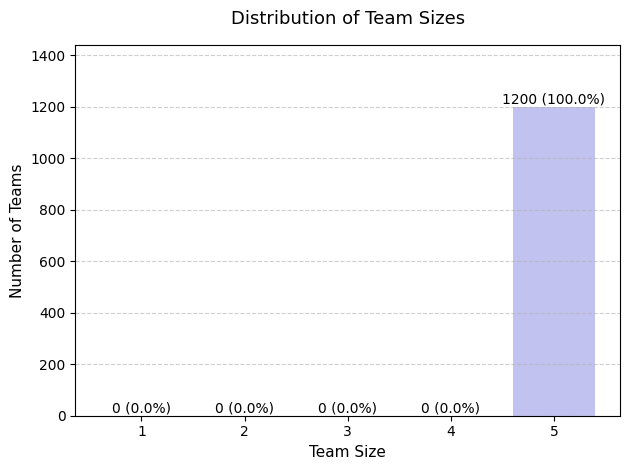

In [ ]:
team_size_counter = obtain_team_size_stats(list_sorted_tutorial_groups)

# Convert to lists for plotting
labels = ["1", "2", "3", "4", "5"]  # expected possible team sizes
counts = [team_size_counter.get(label, 0) for label in labels]


fig, ax = plt.subplots()

bar_colors = ['#ff9999', '#ffcc99', '#99ff99', '#66b3ff', '#c2c2f0']

bars = ax.bar(labels, counts, color=bar_colors)

total = sum(counts)
for bar, count in zip(bars, counts):
    percent = count / total * 100 if total > 0 else 0
    ax.text(bar.get_x() + bar.get_width() / 2, count + 0.2, f"{count} ({percent:.1f}%)", ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Team Size", fontsize=11)
ax.set_ylabel("Number of Teams", fontsize=11)
ax.set_title("Distribution of Team Sizes", fontsize=13, pad=15)

ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(0, max(counts) * 1.2)
plt.tight_layout()
plt.show()

---

## Gender Balance Analysis
Analysis of gender distribution across teams

#### Gender Split Distribution
Pie chart showing breakdown of gender ratios (M2F3, M3F2, M1F4, etc.) across all teams.

#### Gender Diversity Compliance
Percentage of teams meeting gender diversity criteria

Since there are 5 student in each team, the only way for even gender distribution is either M3F2 or M2F3, which is why we set our even gender distribution criteria as either M3F2 or M2F3 is counted as passing the even gender distribution requirement. As shown in the pie chart below, 32.6% of the teams contains M3F2, 64.8% of the teams contain M2F3 and 2.7% of the teams contain M1F4. Thus, this show that only 32 teams which is 2.7% of all the team fail the gender requirement.

#### Gender Diversity Failure Reason
Out of all the teams which failed the gender diversity requirement, it show the reason why each team fail the gender diversity requirement (eg."Due to poor team allocation" or "Due to Gender Imbalance in Tutorial Group"). From the pie chart shown below, out of all the 32 teams that fail the Gender Diversity requirements, 81.2% of the teams, which is 26 teams, failed due to Gender Imbalance in the tutorial group. The remaining 6 teams, which makes up 18.8% of the teams, failed the Gender Diversity requirement due to poor team allocation.

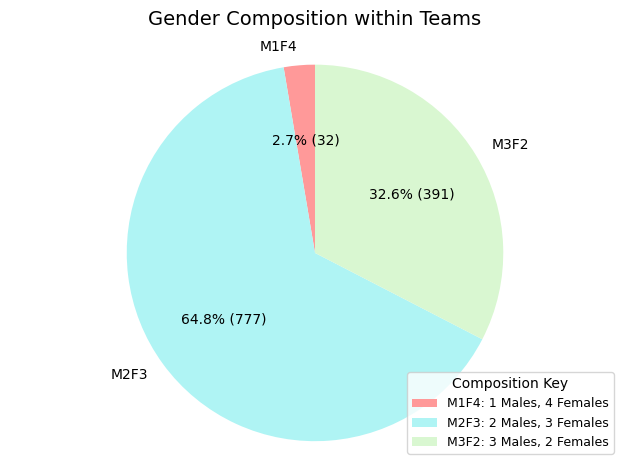

In [ ]:
labels = 'M0F5', 'M1F4', 'M2F3', 'M3F2', 'M4F1', 'M5F0'
gender_composition = obtain_gender_compositions(list_sorted_tutorial_groups)

sizes = []
filtered_labels = []
for label in labels:
    count = gender_composition[label]
    if count > 0:
        sizes.append(count)
        filtered_labels.append(label)

fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(sizes, labels=filtered_labels, autopct=lambda p: f"{p:.1f}% ({int(round(p/100.*sum(sizes)))})", startangle=90, textprops={'fontsize': 10}, colors=['#ff9999',"#aff4f4","#d9f7d1",'#ffcc99','#c2c2f0','#ffb3e6'])

# Equal aspect ratio makes it circular
ax.axis('equal')

ax.set_title("Gender Composition within Teams", fontsize=14, pad=15)

ax.legend(wedges, [f"{label}: {label[1]} Males, {label[3]} Females" for label in filtered_labels], title="Composition Key", loc="best", fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()

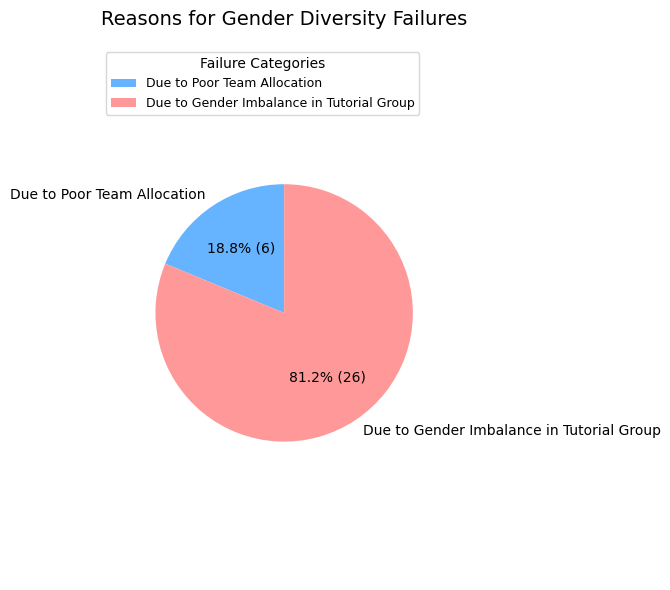

In [ ]:
labels = 'Due to Poor Team Allocation', 'Due to Gender Imbalance in Tutorial Group'
sizes = extra_gender_chart(list_sorted_tutorial_groups)

filtered_sizes = []
filtered_labels = []
for label in labels:
    count = sizes[label]
    if count > 0:
        filtered_sizes.append(count)
        filtered_labels.append(label)

total = sum(filtered_sizes)


fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(filtered_sizes,labels=filtered_labels,autopct=lambda p: f"{p:.1f}% ({int(round(p/100.*total))})",startangle=90,colors=['#66b3ff', '#ff9999'], textprops={'fontsize': 10})

ax.axis('equal')
ax.set_title("Reasons for Gender Diversity Failures", fontsize=14, pad=15)

ax.legend(wedges,filtered_labels,title="Failure Categories",loc="best",fontsize=9,title_fontsize=10)

plt.tight_layout()
plt.show()


---

## School Diversity Analysis
Analysis of school representation across teams

#### School Distribution per Team
Bar chart showing number of different schools represented in each team

#### School Diversity Achievement Rate
Percentage of teams meeting school diversity criteria (no single school majority)

Since it is challenging to have 5 people from different school and meeting the other requirement of Gender and CGPA diversity, we decided to set the passing requirement for school diversity as 2 or less people from same school in each team as in a team of 5, even with 2 people from the same school, there will be 4 unique school present and even with 2 groups of 2 people from same school, there will still be 3 unique school, which means the teams are still diverse as there is no teams with majority of the student being from the same school. Based on the bar graph shown below, 99.5% of the teams have <=2 students from the same school and 0.5% of the teams have 3 students from the same school. This shows that majority of the teams pass the school diversity requirement, as 1194(99.5%) of the team pass the requirement and is diverse while only 6(0.5%) of the teams failed the requirement.

#### Reason for School Diversity Failure
It show the reasons for why the teams fail the school diversity requirement (Due to Poor Team Allocation or Due to Lack of School Diversity in Tutorial Group). As shown in the pie chart below, 100% of the teams that fail the School Diversity requirement is due to poor team allocation.


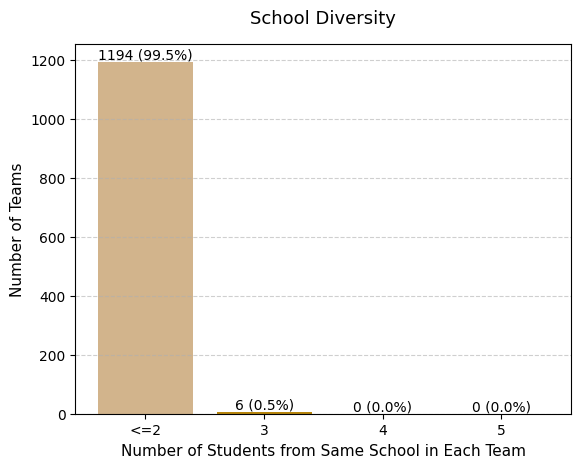

In [ ]:
fig, ax = plt.subplots()
student_variations = ["<=2", "3", "4", "5"]
sizes = obtain_school_composition(list_sorted_tutorial_groups)
counts = []
for i in student_variations:
    counts.append(sizes[i])

total = sum(counts)

bar_colors = ['tan', 'darkgoldenrod','darkorange', 'bisque']

bars = ax.bar(student_variations, counts, color=bar_colors)

ax.set_ylabel('Number of Teams', fontsize = 11)
ax.set_xlabel('Number of Students from Same School in Each Team', fontsize = 11)
ax.set_title('School Diversity', fontsize=13, pad=15)
ax.grid(axis='y',linestyle='--', alpha=0.6)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    percent = count / total * 100 if total > 0 else 0
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3, f'{count} ({percent:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.show()

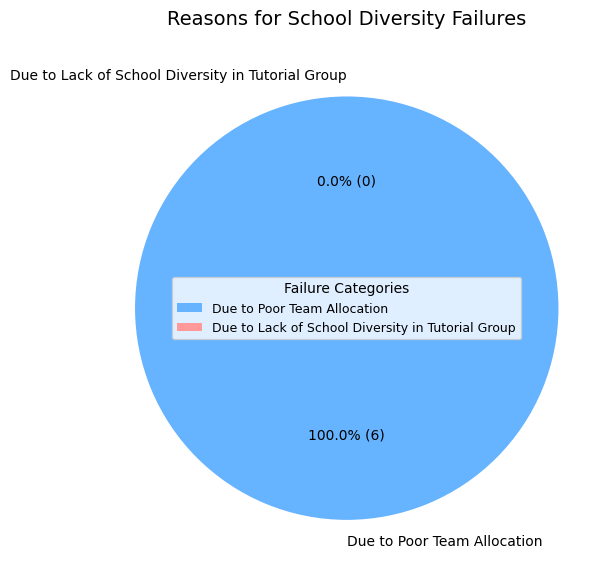

In [ ]:

labels = 'Due to Poor Team Allocation', 'Due to Lack of School Diversity in Tutorial Group'
sizes = extra_school_chart(list_sorted_tutorial_groups)

filtered_sizes = []
filtered_labels = []
for label in labels:
    count = sizes[label]
    if count >= 0:
        filtered_sizes.append(count)
        filtered_labels.append(label)

total = sum(filtered_sizes)

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(filtered_sizes,labels=filtered_labels,autopct=lambda p: f"{p:.1f}% ({int(round(p/100.*total))})",startangle=90,colors=['#66b3ff', '#ff9999'], textprops={'fontsize': 10})

ax.axis('equal')

ax.set_title("Reasons for School Diversity Failures", fontsize=14, pad=15)

ax.legend(wedges,labels,title="Failure Categories",loc="best",fontsize=9,title_fontsize=10)

plt.tight_layout()
plt.show()





---


## CGPA Diversity
Analysis of CGPA variation across teams

### Team CGPA Consistency
Pie chart showing the percentage of teams with a standard deviation of mean CGPA less than 0.1. With a standard deviation of <0.1 for the mean CGPA, this means that all the mean CGPA of all the teams within a tutorial group has the difference of less than 0.1 which shows that the students are evenly distributed accordingly to their CGPA with no team having all students with high CPGA or low CGPA. Based on the pie chart shown below, 100% of the teams have a <0.1 standard deviation of mean CGPA between the teams within the tutorial group, thus showing that all student are fairly distributed according to their CGPA and meeting the requirement of having a diverse CGPA with the teams.

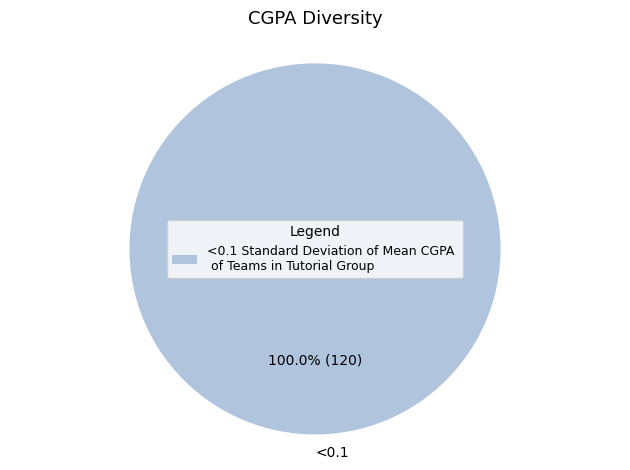

In [ ]:
labels = "<0.1", ">= 0.1"
sizes = obtain_cgpa_stats(list_sorted_tutorial_groups)

filtered_labels = []
filtered_sizes = []
for label, size in zip(labels, sizes):
    if size > 0:
        filtered_labels.append(label)
        filtered_sizes.append(size)


total = sum(filtered_sizes)

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(filtered_sizes, labels=filtered_labels, autopct=lambda p: f"{p:.1f}% ({int(round(p/100.*total))})", startangle=90, colors=['lightsteelblue', '#ff9999'], textprops={'fontsize': 10})

ax.axis('equal')
ax.set_title("CGPA Diversity", fontsize=13, pad=15)

ax.legend(wedges, [f"{label} Standard Deviation of Mean CGPA \n of Teams in Tutorial Group" for label in filtered_labels], title="Legend", loc="best", fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()




---


# **Conclusion**


## Challenges and Issues

* **Imbalanced Inputs:** Some tutorial groups had skewed demographics (e.g., mostly one gender or from one school), making it impossible to create perfectly balanced teams in every case.
* **Library Constraints:** The restriction against using **`pandas`** or **`numpy`** made data handling difficult. Managing thousands of records using only basic lists and dictionaries was tedious and increased the risk of errors.
* **Algorithm Design:** Developing an effective, non-random allocation algorithm required significant trial and error to get it working smoothly.
* **Group Coordination:** Working as a team meant we had to align different coding styles and explanation methods, which was a challenge.

---

## Key Learnings and Takeaways

* **Practical Problem-Solving:** We successfully translated a complex, real-world problem (forming diverse student teams) into a solvable, step-by-step computational solution.
* **Data-Driven Logic:** The project highlighted the importance of clear planning and logic when handling large datasets, especially without advanced libraries.
* **Balancing Variables:** We learned to design rules that balanced multiple competing criteria simultaneously (school background, gender, and CGPA).
* **Applied Computational Thinking:** The project was a clear exercise in computational thinking: decomposing the problem, designing logical rules, and iteratively testing the solution until it produced sensible results.